# 🛒 E-Commerce Sales Data Analysis & Visualization

This notebook performs an end-to-end **Exploratory Data Analysis (EDA)** of an e-commerce (Superstore) sales dataset using **Python, NumPy, Pandas, Matplotlib, and Seaborn**.

**Goal:** To Analyze (sales, profit, customers, products, categories, regions, discounts, and time-based trends, and translate the findings into meaningful visualizations and actionable business insights).

### 📑 Table of Contents
1. [Setup & Imports](#1)
2. [Load Data](#2)
3. [Data Overview](#3)
4. [Data Cleaning & Preprocessing](#4)
5. [Descriptive Statistics](#5)
6. [Overall Sales & Profit Analysis](#6)
7. [Time-Based Trends (Monthly & Yearly)](#7)
8. [Category & Sub-Category Performance](#8)
9. [Regional Sales Analysis](#9)
10. [Top-Performing Products](#10)
11. [Customer & Segment Analysis](#11)
12. [Discount vs Profit Analysis](#12)
13. [Correlation Analysis](#13)
14. [Additional Statistical & Categorical Visualizations](#14)
15. [Key Business Insights & Conclusions](#15)


<a id='1'></a>
## 1. Setup & Imports

In [52]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.savefig("../visualizations/monthly_sales.png", dpi=300)

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Libraries imported successfully.")

Libraries imported successfully.


<Figure size 1000x600 with 0 Axes>

<a id='2'></a>
## 2. Load Data

In [53]:
# Load the dataset
df = pd.read_csv("../data/Superstore_Sales.csv", encoding="latin1")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 8399 rows x 21 columns


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,Shipping Cost,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.54,0.04,Regular Air,-213.25,38.94,35.00,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,"10,123.02",0.07,Delivery Truck,457.81,208.16,68.02,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.57,0.01,Regular Air,46.71,8.69,2.99,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D® Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,7/10/2011,High,30,"4,965.76",0.08,Regular Air,"1,198.97",195.99,3.99,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,8/28/2010,Not Specified,19,394.27,0.08,Regular Air,30.94,21.78,5.94,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


<a id='3'></a>
## 3. Data Overview

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Row ID                8399 non-null   int64  
 1   Order ID              8399 non-null   int64  
 2   Order Date            8399 non-null   object 
 3   Order Priority        8399 non-null   object 
 4   Order Quantity        8399 non-null   int64  
 5   Sales                 8399 non-null   float64
 6   Discount              8399 non-null   float64
 7   Ship Mode             8399 non-null   object 
 8   Profit                8399 non-null   float64
 9   Unit Price            8399 non-null   float64
 10  Shipping Cost         8399 non-null   float64
 11  Customer Name         8399 non-null   object 
 12  Province              8399 non-null   object 
 13  Region                8399 non-null   object 
 14  Customer Segment      8399 non-null   object 
 15  Product Category     

In [55]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Row ID', 'Order ID', 'Order Date', 'Order Priority', 'Order Quantity', 'Sales', 'Discount', 'Ship Mode', 'Profit', 'Unit Price', 'Shipping Cost', 'Customer Name', 'Province', 'Region', 'Customer Segment', 'Product Category', 'Product Sub-Category', 'Product Name', 'Product Container', 'Product Base Margin', 'Ship Date']


In [56]:
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0')

Missing values per column:


,Missing Count,Missing %
Product Base Margin,63,0.75


In [57]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


<a id='4'></a>
## 4. Data Cleaning & Preprocessing

Steps performed:
- Convert date columns to proper `datetime` type
- Handle missing values in `Product Base Margin` (fill with sub-category median)
- Create time-based helper columns (Year, Month, Month-Year, Quarter)
- Create a `Shipping Duration` feature (days between order and ship date)
- Create a `Profit Margin` feature (Profit / Sales)


In [58]:
# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Fill missing Product Base Margin with the median of its Product Sub-Category
df['Product Base Margin'] = df.groupby('Product Sub-Category')['Product Base Margin']\
                                .transform(lambda x: x.fillna(x.median()))
# Fallback: fill any remaining NaNs with overall median
df['Product Base Margin'] = df['Product Base Margin'].fillna(df['Product Base Margin'].median())

# Remove exact duplicate rows, if any
df.drop_duplicates(inplace=True)

# Feature engineering - time based
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.month_name()
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Month-Year'] = df['Order Date'].dt.to_period('M').astype(str)

# Feature engineering - operational
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin'] = df['Profit'] / df['Sales']

print("Data cleaning complete.")
print("Remaining missing values:", df.isnull().sum().sum())
df.head()

Data cleaning complete.
Remaining missing values: 0


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,Shipping Cost,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date,Order Year,Order Month,Order Month Name,Order Quarter,Month-Year,Shipping Duration,Profit Margin
0,1,3,2010-10-13,Low,6,261.54,0.04,Regular Air,-213.25,38.94,35.00,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,2010-10-20,2010,10,October,4,2010-10,7,-0.82
1,49,293,2012-10-01,High,49,"10,123.02",0.07,Delivery Truck,457.81,208.16,68.02,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,2012-10-02,2012,10,October,4,2012-10,1,0.05
2,50,293,2012-10-01,High,27,244.57,0.01,Regular Air,46.71,8.69,2.99,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D® Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,2012-10-03,2012,10,October,4,2012-10,2,0.19
3,80,483,2011-07-10,High,30,"4,965.76",0.08,Regular Air,"1,198.97",195.99,3.99,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,2011-07-12,2011,7,July,3,2011-07,2,0.24
4,85,515,2010-08-28,Not Specified,19,394.27,0.08,Regular Air,30.94,21.78,5.94,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,2010-08-30,2010,8,August,3,2010-08,2,0.08


<a id='5'></a>
## 5. Descriptive Statistics

In [59]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,"8,399.00","4,200.00",1.00,"2,100.50","4,200.00","6,299.50","8,399.00","2,424.73"
Order ID,"8,399.00","29,965.18",3.00,"15,011.50","29,857.00","44,596.00","59,973.00","17,260.88"
Order Date,8399,2010-12-25 00:40:58.578402048,2009-01-01 00:00:00,2009-12-20 00:00:00,2010-12-17 00:00:00,2012-01-01 12:00:00,2012-12-30 00:00:00,NaN
Order Quantity,"8,399.00",25.57,1.00,13.00,26.00,38.00,50.00,14.48
Sales,"8,399.00","1,775.88",2.24,143.19,449.42,"1,709.32","89,061.05","3,585.05"
Discount,"8,399.00",0.05,0.00,0.02,0.05,0.08,0.25,0.03
Profit,"8,399.00",181.18,"-14,140.70",-83.31,-1.50,162.75,"27,220.69","1,196.65"
Unit Price,"8,399.00",89.35,0.99,6.48,20.99,85.99,"6,783.02",290.35
Shipping Cost,"8,399.00",12.84,0.49,3.30,6.07,13.99,164.73,17.26
Product Base Margin,"8,399.00",0.51,0.35,0.38,0.52,0.59,0.85,0.14


In [60]:
print("Categorical column overview:\n")
for col in ['Order Priority', 'Ship Mode', 'Region', 'Customer Segment',
            'Product Category', 'Product Sub-Category', 'Product Container']:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts())
    print()

Categorical column overview:

--- Order Priority (5 unique) ---
Order Priority
High             1768
Low              1720
Not Specified    1672
Medium           1631
Critical         1608
Name: count, dtype: int64

--- Ship Mode (3 unique) ---
Ship Mode
Regular Air       6270
Delivery Truck    1146
Express Air        983
Name: count, dtype: int64

--- Region (8 unique) ---
Region
West                     1991
Ontario                  1826
Prarie                   1706
Atlantic                 1080
Quebec                    781
Yukon                     542
Northwest Territories     394
Nunavut                    79
Name: count, dtype: int64

--- Customer Segment (4 unique) ---
Customer Segment
Corporate         3076
Home Office       2032
Consumer          1649
Small Business    1642
Name: count, dtype: int64

--- Product Category (3 unique) ---
Product Category
Office Supplies    4610
Technology         2065
Furniture          1724
Name: count, dtype: int64

--- Product Sub-Category 

<a id='6'></a>
## 6. Overall Sales & Profit Analysis

Headline KPIs for the whole dataset.


In [61]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = df.groupby('Order ID')['Sales'].sum().mean()
overall_margin = total_profit / total_sales * 100

print(f"Total Sales:          ${total_sales:,.2f}")
print(f"Total Profit:         ${total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_margin:.2f}%")
print(f"Unique Orders:        {total_orders:,}")
print(f"Average Order Value:  ${avg_order_value:,.2f}")
print(f"Total Units Sold:     {df['Order Quantity'].sum():,}")

Total Sales:          $14,915,600.82
Total Profit:         $1,521,767.98
Overall Profit Margin: 10.20%
Unique Orders:        5,496
Average Order Value:  $2,713.90
Total Units Sold:     214,777


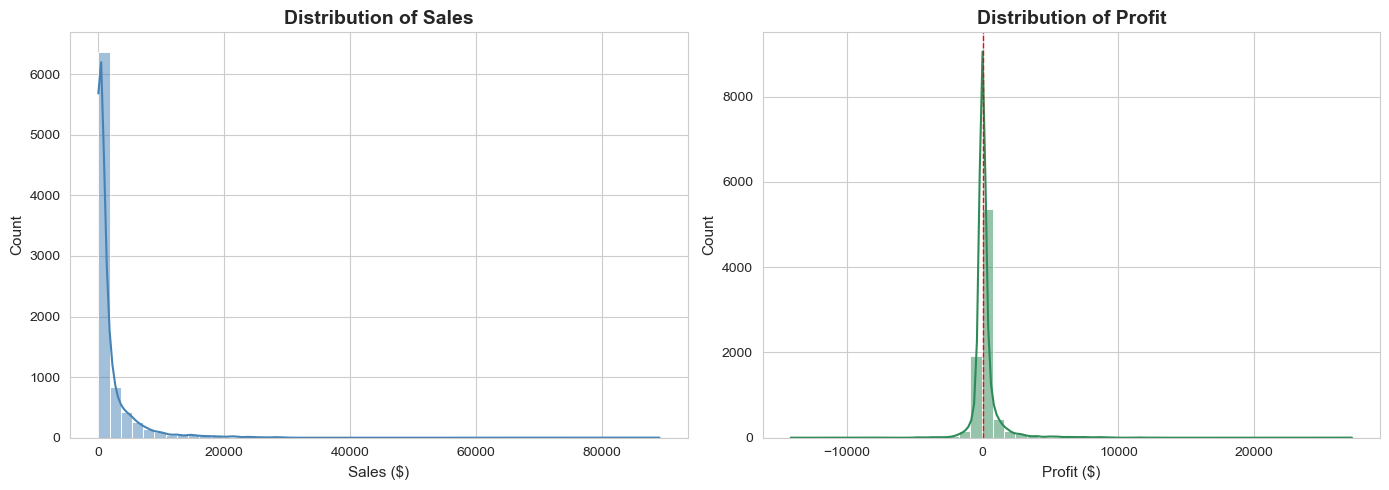

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Sales')
axes[0].set_xlabel('Sales ($)')

sns.histplot(df['Profit'], bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Profit')
axes[1].set_xlabel('Profit ($)')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('../visualizations/sales_profit_distribution.png',
            dpi=300,
            bbox_inches='tight')
plt.show()

<a id='7'></a>
## 7. Time-Based Trends (Monthly & Yearly)


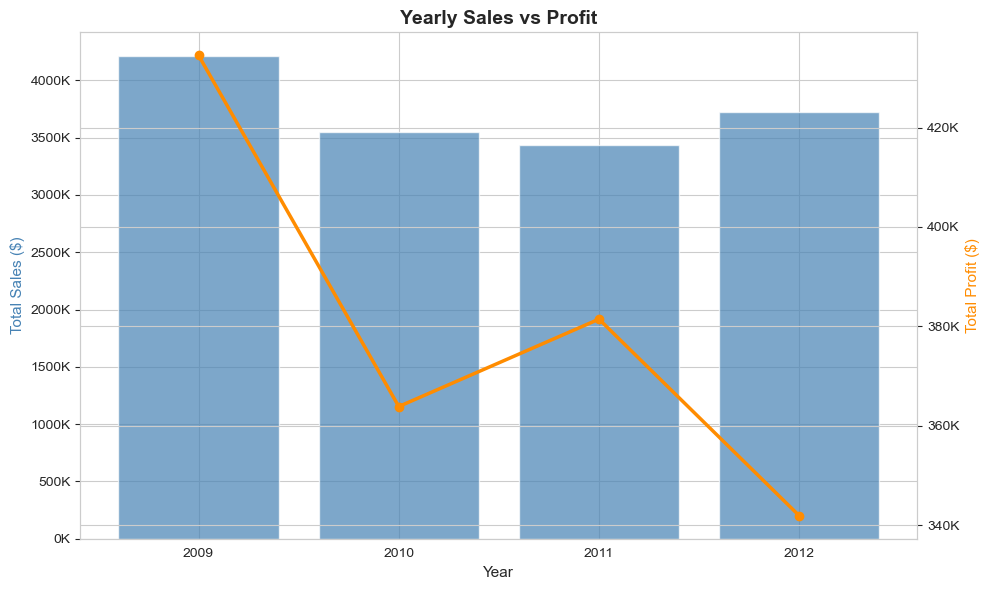

In [73]:
yearly = df.groupby('Order Year').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.bar(yearly['Order Year'], yearly['Sales'], color='steelblue', alpha=0.7, label='Sales')
ax2.plot(yearly['Order Year'], yearly['Profit'], color='darkorange', marker='o', linewidth=2.5, label='Profit')

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Sales ($)', color='steelblue')
ax2.set_ylabel('Total Profit ($)', color='darkorange')
ax1.set_xticks(yearly['Order Year'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.title('Yearly Sales vs Profit')

fig.tight_layout()
plt.savefig('../visualizations/yearly_sales_profit_distribution.png',
            dpi=300,
            bbox_inches='tight')
plt.show()

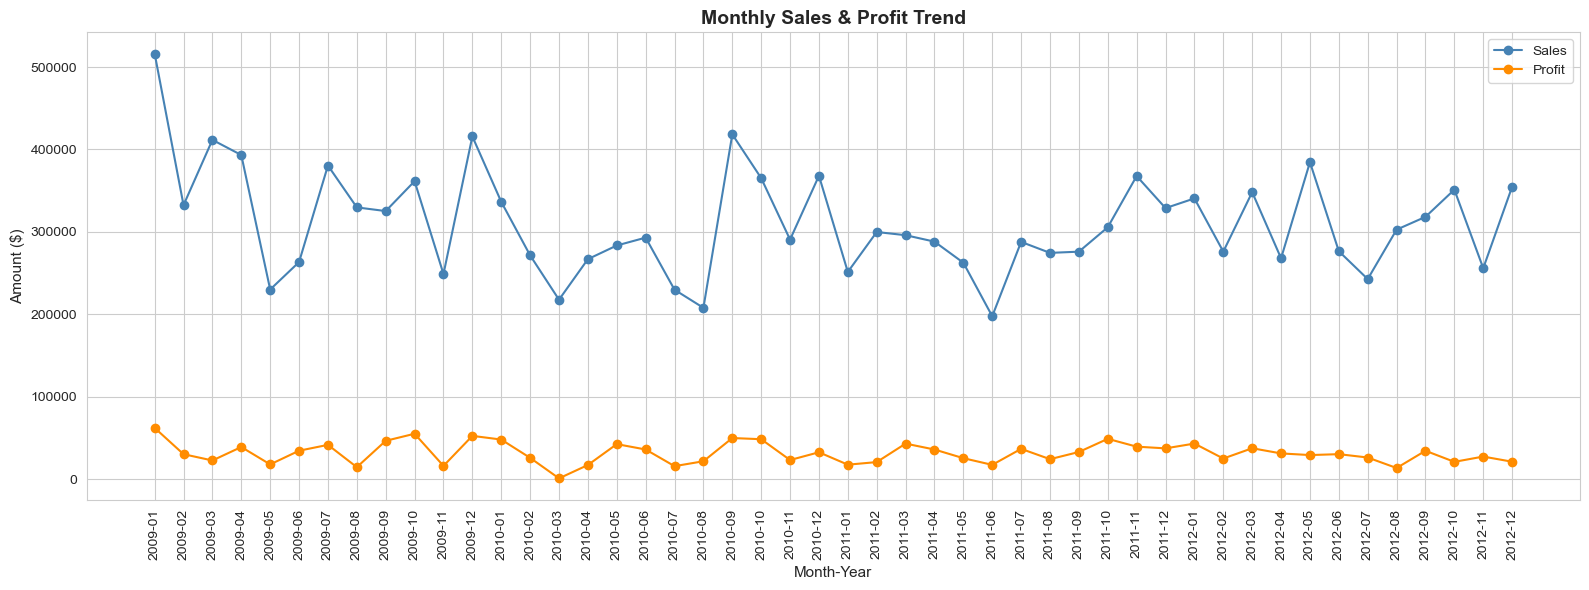

In [74]:
monthly = df.groupby('Month-Year').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).reset_index()
monthly = monthly.sort_values('Month-Year')

plt.figure(figsize=(16, 6))
plt.plot(monthly['Month-Year'], monthly['Sales'], marker='o', label='Sales', color='steelblue')
plt.plot(monthly['Month-Year'], monthly['Profit'], marker='o', label='Profit', color='darkorange')
plt.xticks(rotation=90)
plt.title('Monthly Sales & Profit Trend')
plt.xlabel('Month-Year')
plt.ylabel('Amount ($)')
plt.legend()

plt.tight_layout()
plt.savefig('../visualizations/monthly_sales_and_profit_trend_distribution.png',
            dpi=300,
            bbox_inches='tight')
plt.show()

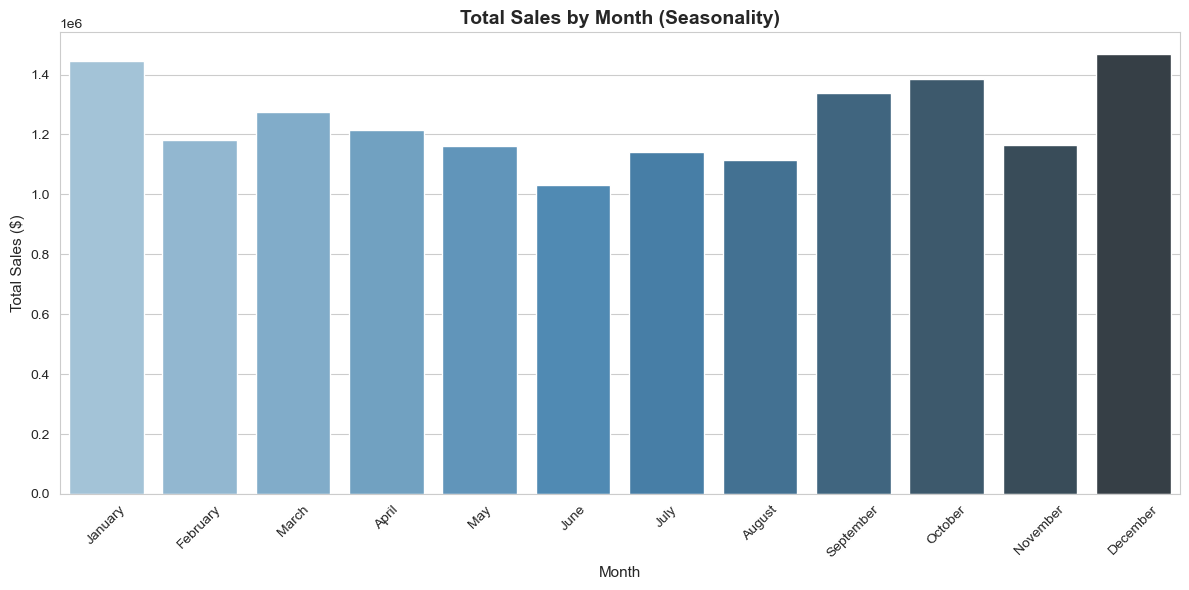

In [75]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
seasonal = df.groupby('Order Month Name')['Sales'].sum().reindex(month_order)

plt.figure(figsize=(12, 6))
sns.barplot(x=seasonal.index, y=seasonal.values, palette='Blues_d')
plt.title('Total Sales by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visualizations/sales_profit_distribution.png',
            dpi=300,
            bbox_inches='tight')
plt.show()


<a id='8'></a>
## 8. Category & Sub-Category Performance


In [66]:
cat_perf = df.groupby('Product Category').agg(
    Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Orders=('Order ID', 'nunique')
).sort_values('Sales', ascending=False)
cat_perf


,Sales,Profit,Orders
Product Category,,,
Technology,"5,984,248.18","886,313.52",1858
Furniture,"5,178,590.54","117,433.03",1561
Office Supplies,"3,752,762.10","518,021.43",3632


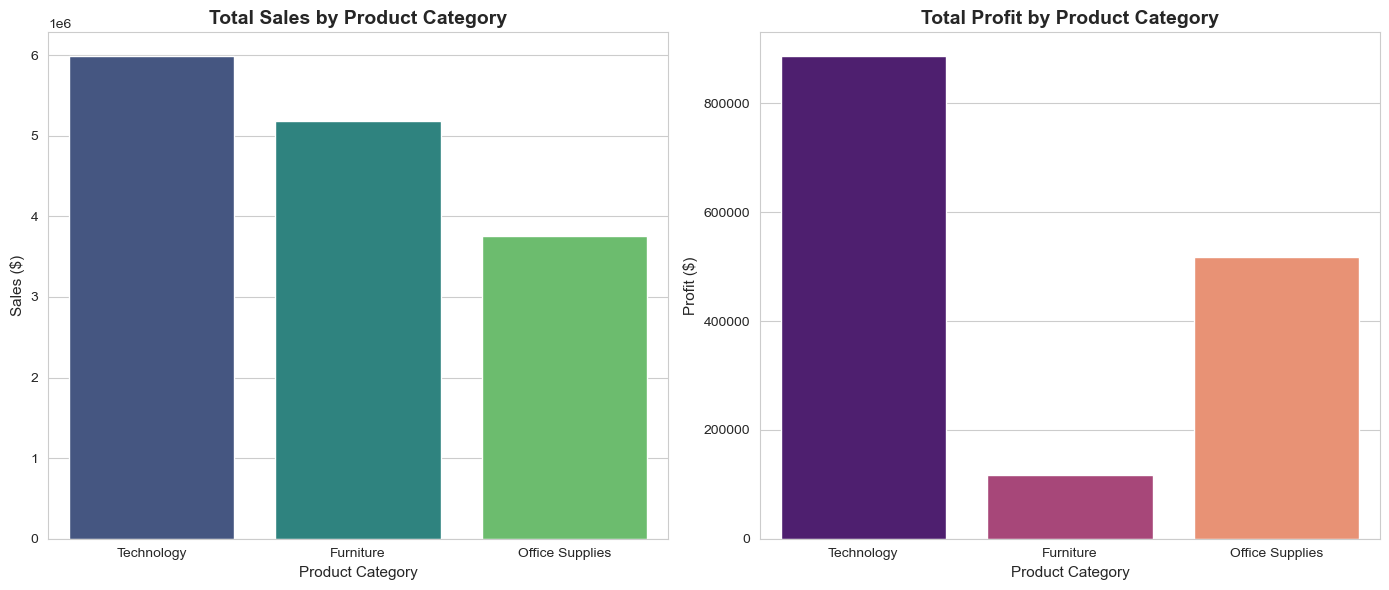

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=cat_perf.index, y=cat_perf['Sales'], ax=axes[0], palette='viridis')
axes[0].set_title('Total Sales by Product Category')
axes[0].set_ylabel('Sales ($)')

sns.barplot(x=cat_perf.index, y=cat_perf['Profit'], ax=axes[1], palette='magma')
axes[1].set_title('Total Profit by Product Category')
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.savefig(
    '../visualizations/category_sales_profit.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


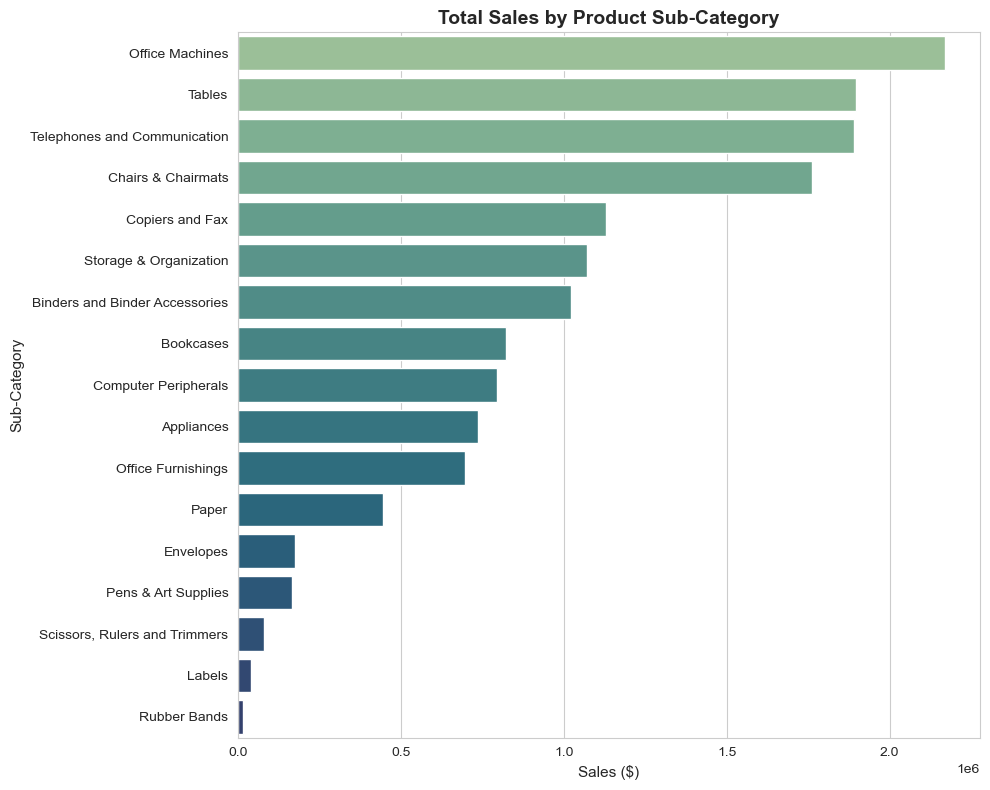

In [78]:
subcat_perf = df.groupby('Product Sub-Category').agg(
    Sales=('Sales', 'sum'), Profit=('Profit', 'sum')
).sort_values('Sales', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=subcat_perf['Sales'], y=subcat_perf.index, palette='crest')
plt.title('Total Sales by Product Sub-Category')
plt.xlabel('Sales ($)')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.savefig(
    '../visualizations/subcategory_sales.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


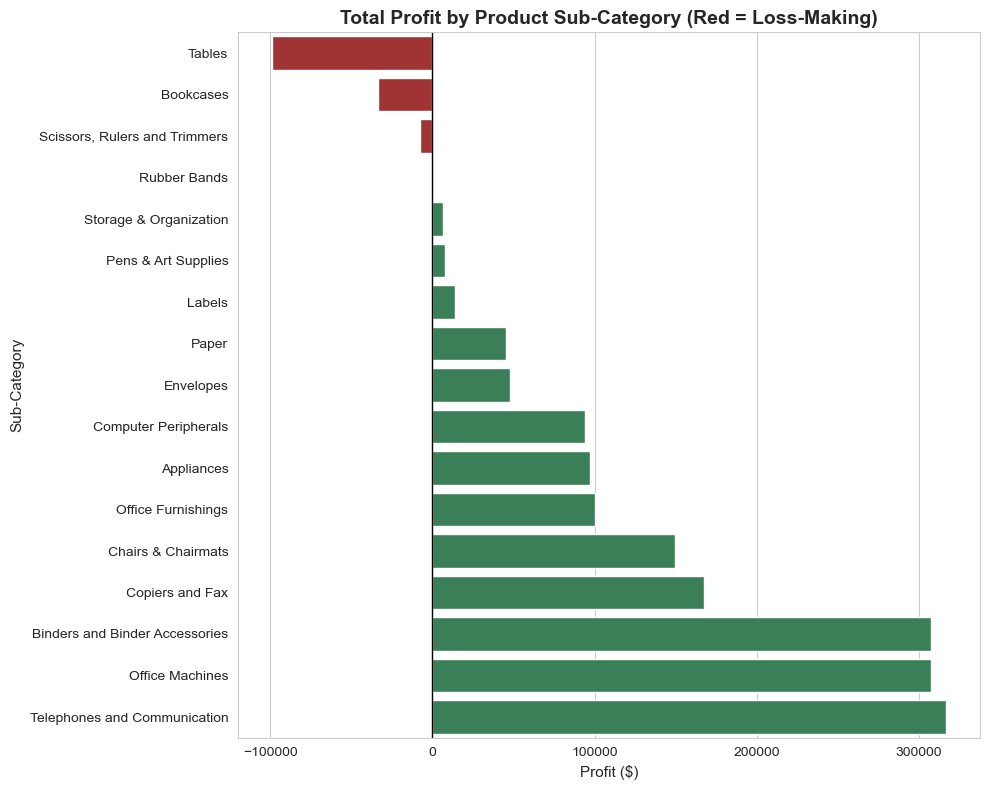

In [79]:
plt.figure(figsize=(10, 8))
colors = ['seagreen' if v >= 0 else 'firebrick' for v in subcat_perf.sort_values('Profit')['Profit']]
sns.barplot(x=subcat_perf.sort_values('Profit')['Profit'],
            y=subcat_perf.sort_values('Profit').index, palette=colors)
plt.title('Total Profit by Product Sub-Category (Red = Loss-Making)')
plt.xlabel('Profit ($)')
plt.ylabel('Sub-Category')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig(
    '../visualizations/subcategory_profit.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


<a id='9'></a>
## 9. Regional Sales Analysis


In [23]:
region_perf = df.groupby('Region').agg(
    Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Orders=('Order ID', 'nunique')
).sort_values('Sales', ascending=False)
region_perf


,Sales,Profit,Orders
Region,,,
West,"3,597,549.28","297,008.61",1330
Ontario,"3,063,212.48","346,868.54",1235
Prarie,"2,837,304.60","321,160.12",1148
Atlantic,"2,014,248.20","238,960.66",748
Quebec,"1,510,195.08","140,426.65",587
Yukon,"975,867.37","73,849.21",396
Northwest Territories,"800,847.33","100,653.08",269
Nunavut,"116,376.48","2,841.11",56


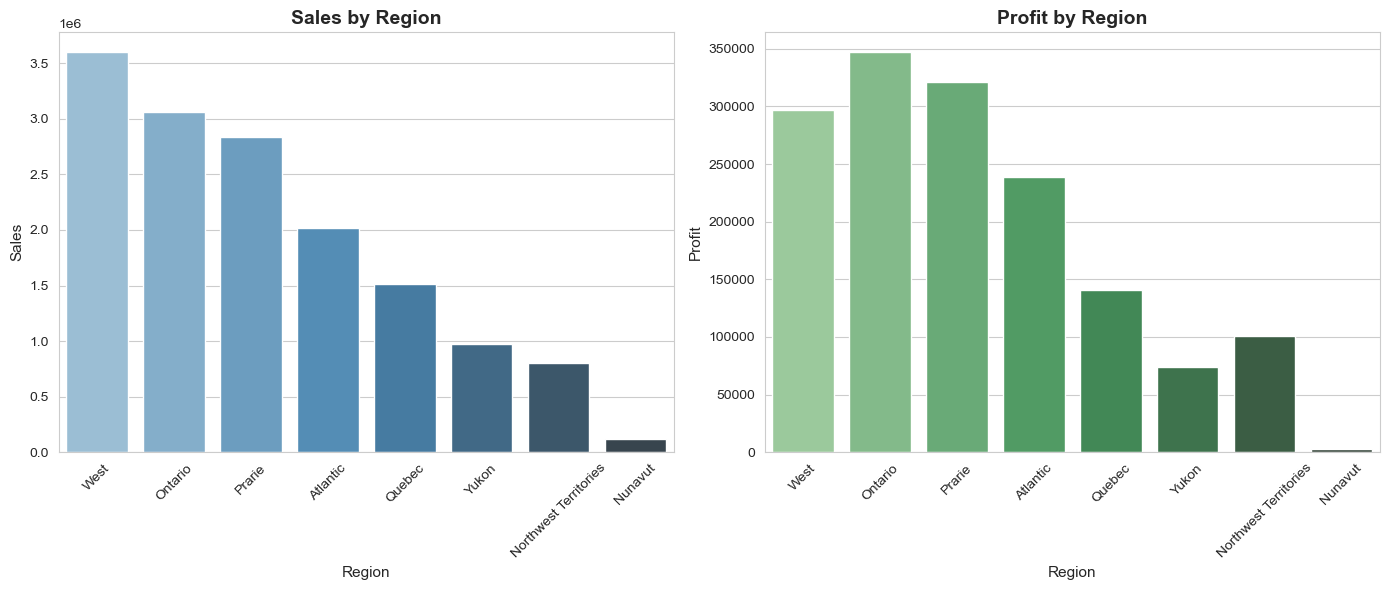

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=region_perf.index, y=region_perf['Sales'], ax=axes[0], palette='Blues_d')
axes[0].set_title('Sales by Region')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=region_perf.index, y=region_perf['Profit'], ax=axes[1], palette='Greens_d')
axes[1].set_title('Profit by Region')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(
    '../visualizations/regional_sales_profit.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


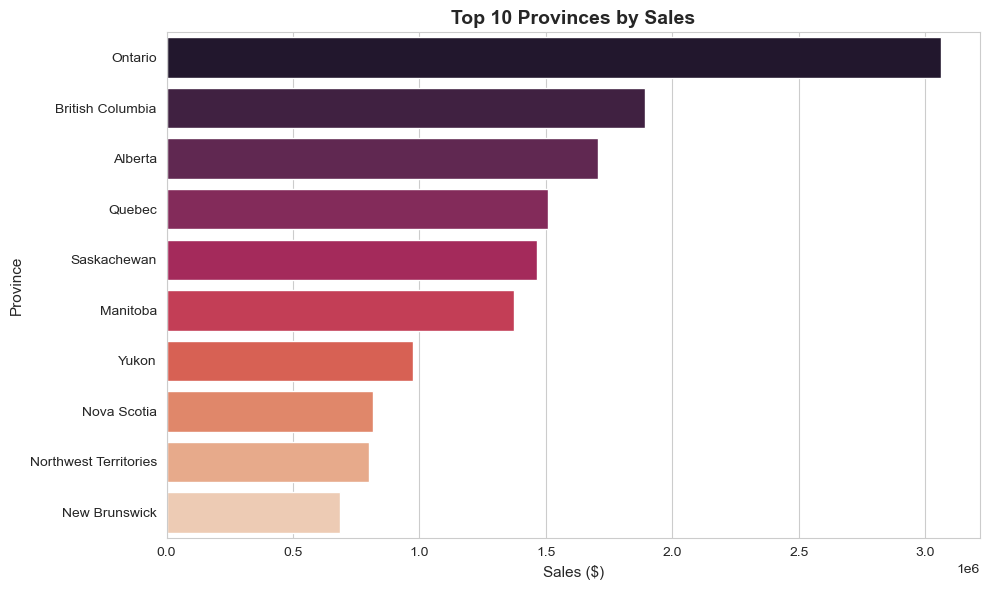

In [81]:
top_provinces = df.groupby('Province')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_provinces.values, y=top_provinces.index, palette='rocket')
plt.title('Top 10 Provinces by Sales')
plt.xlabel('Sales ($)')
plt.tight_layout()
plt.savefig(
    '../visualizations/top_10_provinces_sales.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


<a id='10'></a>
## 10. Top-Performing Products


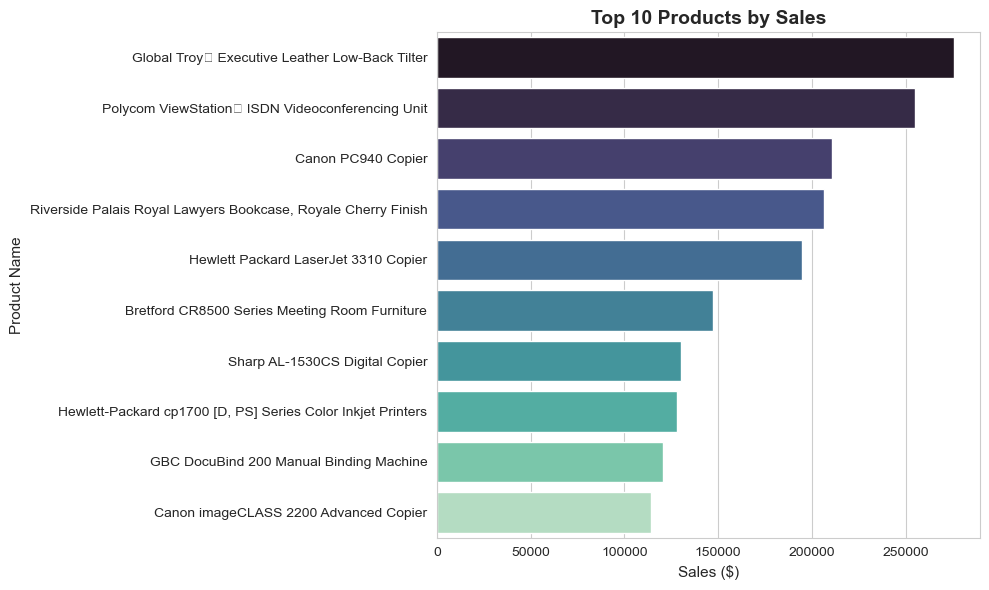

In [82]:
top_products_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products_sales.values, y=top_products_sales.index, palette='mako')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales ($)')
plt.tight_layout()
plt.savefig(
    '../visualizations/top_10_products_sales.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


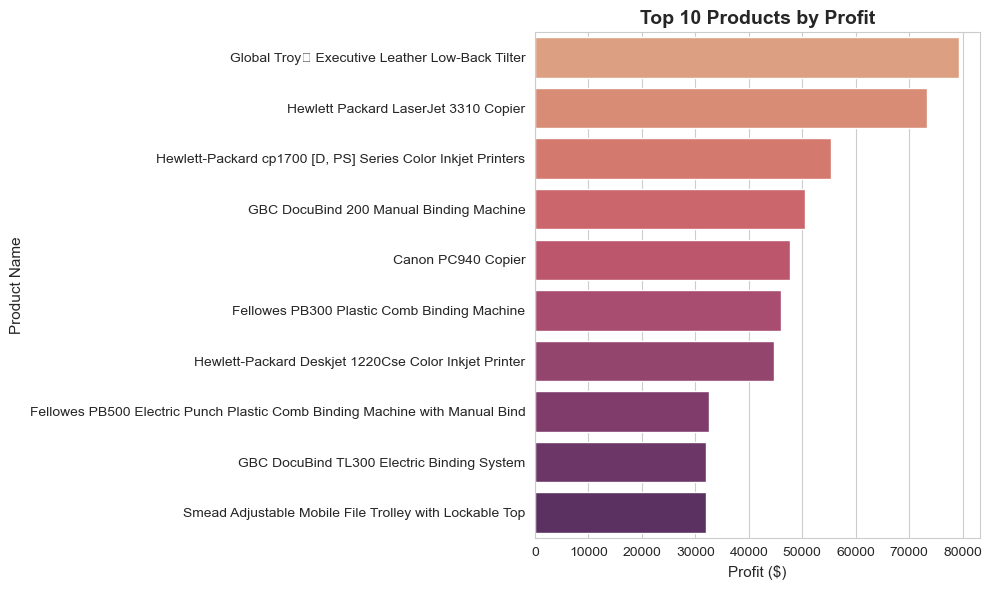

In [83]:
top_products_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products_profit.values, y=top_products_profit.index, palette='flare')
plt.title('Top 10 Products by Profit')
plt.xlabel('Profit ($)')
plt.tight_layout()
plt.savefig(
    '../visualizations/top_10_products_profit.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


In [28]:
least_products_profit = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)
print("Top 10 Least Profitable (Loss-Making) Products:")
least_products_profit


Top 10 Least Profitable (Loss-Making) Products:


Product Name
Okidata Pacemark 4410N Wide Format Dot Matrix Printer               -43,949.37
Canon imageCLASS 2200 Advanced Copier                               -31,885.68
Global High-Back Leather Tilter, Burgundy                           -30,518.90
Epson DFX-8500 Dot Matrix Printer                                   -29,400.34
Hoover Portapower Portable Vacuum                                  -21,088.48
Polycom ViewStation ISDN Videoconferencing Unit                    -17,771.27
Epson DFX5000+ Dot Matrix Printer                                   -16,160.74
KI Conference Tables                                                -15,701.27
Lexmark 4227 Plus Dot Matrix Printer                                -15,492.81
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -14,938.68
Name: Profit, dtype: float64

<a id='11'></a>
## 11. Customer & Segment Analysis


In [29]:
segment_perf = df.groupby('Customer Segment').agg(
    Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Orders=('Order ID', 'nunique')
).sort_values('Sales', ascending=False)
segment_perf


,Sales,Profit,Orders
Customer Segment,,,
Corporate,"5,498,904.88","599,746.00",2002
Home Office,"3,564,763.88","318,354.03",1341
Consumer,"3,063,611.08","287,959.94",1076
Small Business,"2,788,320.99","315,708.01",1077


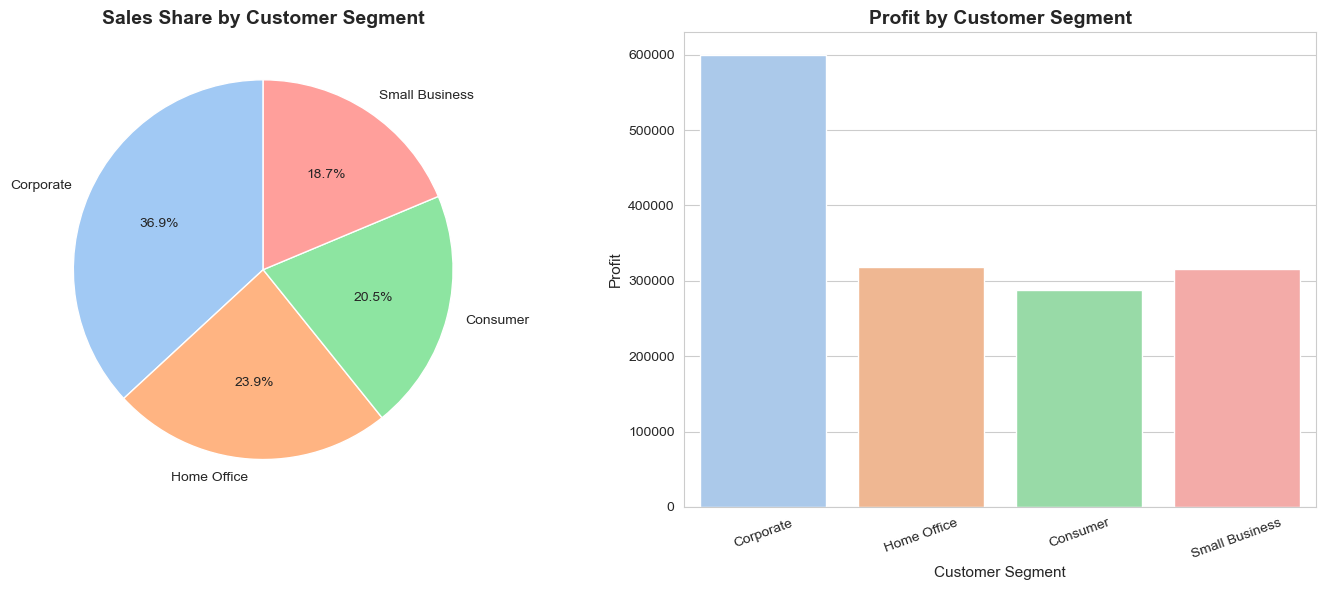

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(segment_perf['Sales'], labels=segment_perf.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'), startangle=90)
axes[0].set_title('Sales Share by Customer Segment')

sns.barplot(x=segment_perf.index, y=segment_perf['Profit'], ax=axes[1], palette='pastel')
axes[1].set_title('Profit by Customer Segment')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(
    '../visualizations/customer_segment_analysis.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

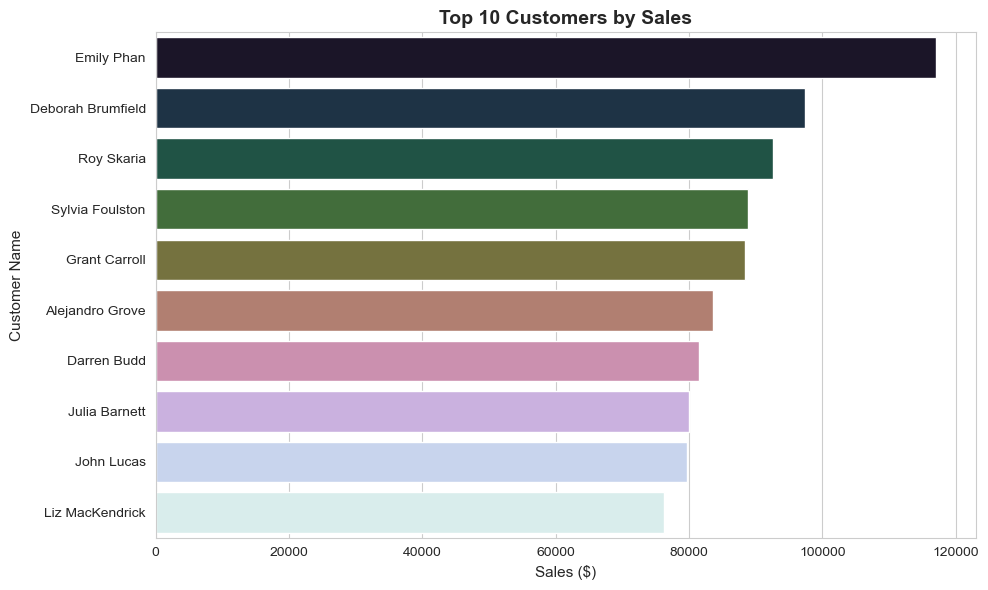

In [31]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers.values, y=top_customers.index, palette='cubehelix')
plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales ($)')
plt.tight_layout()
plt.show()


<a id='12'></a>
## 12. Discount vs Profit Analysis


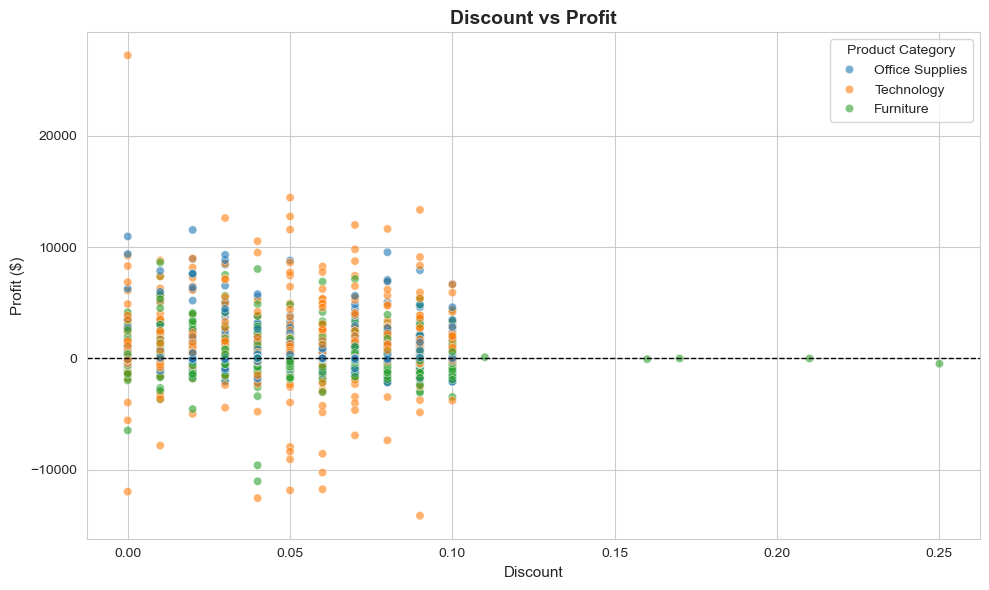

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Product Category', alpha=0.6)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.tight_layout()
plt.show()


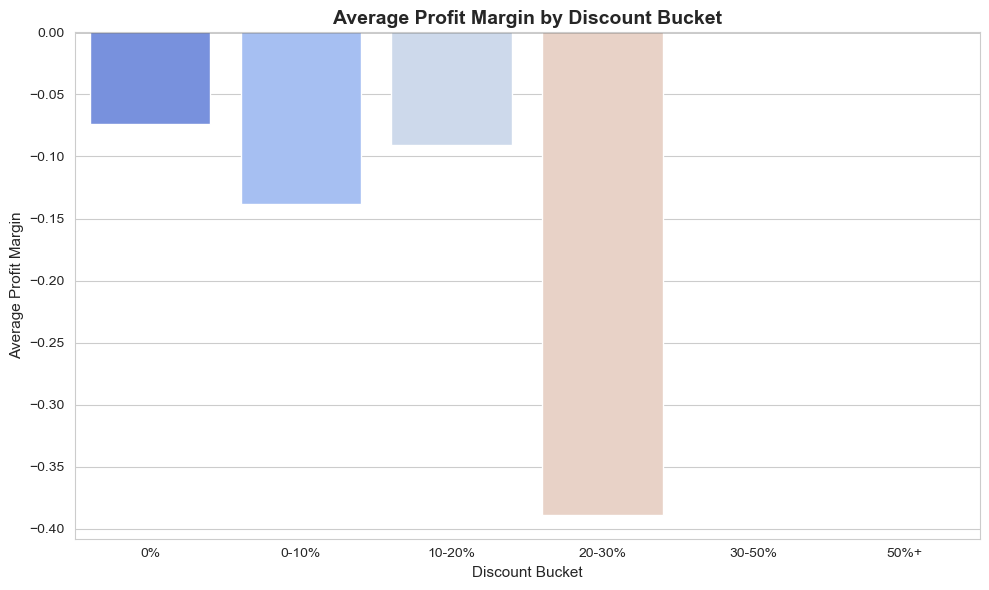

In [33]:
# Bucket discounts to see average profit margin per bucket
df['Discount Bucket'] = pd.cut(df['Discount'], bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1],
                                 labels=['0%', '0-10%', '10-20%', '20-30%', '30-50%', '50%+'])
discount_profit = df.groupby('Discount Bucket')['Profit Margin'].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=discount_profit.index, y=discount_profit.values, palette='coolwarm')
plt.title('Average Profit Margin by Discount Bucket')
plt.xlabel('Discount Bucket')
plt.ylabel('Average Profit Margin')
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()


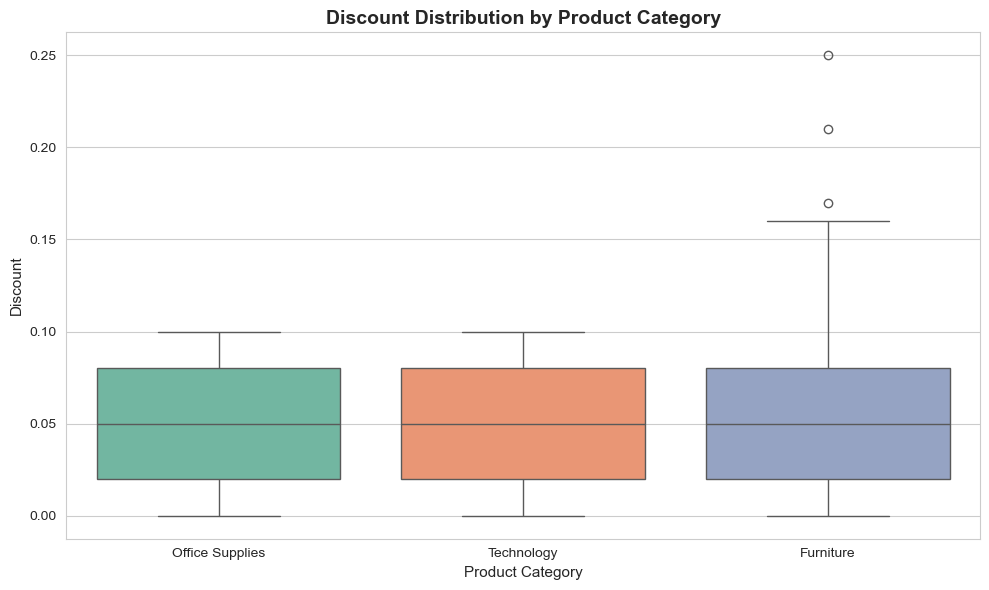

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Product Category', y='Discount', palette='Set2')
plt.title('Discount Distribution by Product Category')
plt.tight_layout()
plt.show()


<a id='13'></a>
## 13. Correlation Analysis


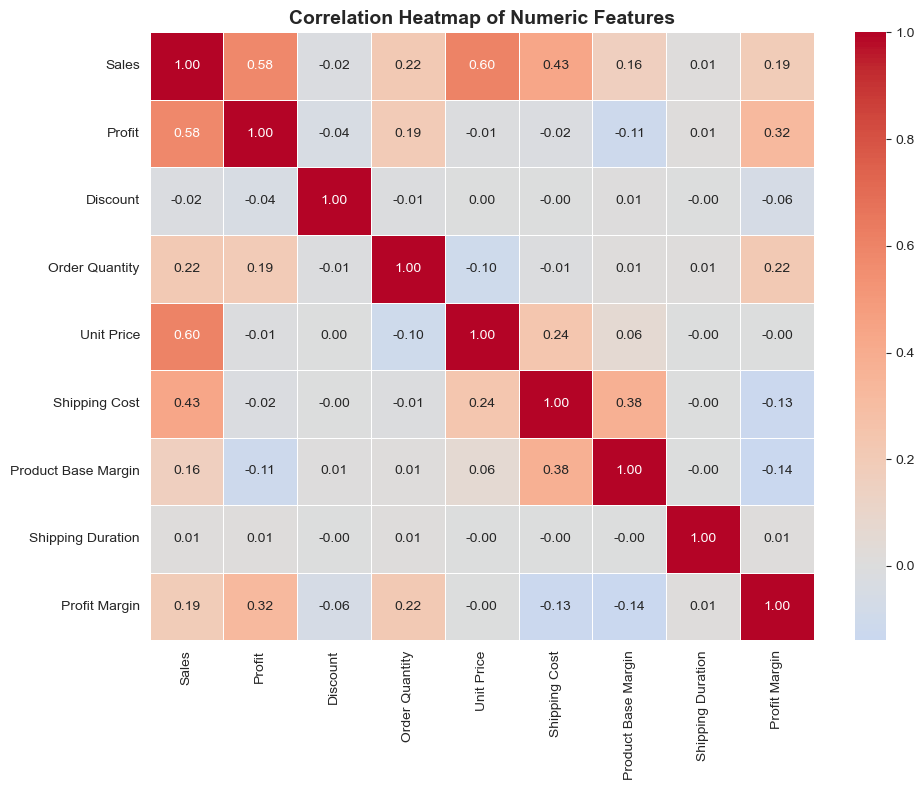

In [35]:
numeric_cols = ['Sales', 'Profit', 'Discount', 'Order Quantity', 'Unit Price',
                'Shipping Cost', 'Product Base Margin', 'Shipping Duration', 'Profit Margin']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


<a id='14'></a>
## 14. Additional Statistical & Categorical Visualizations


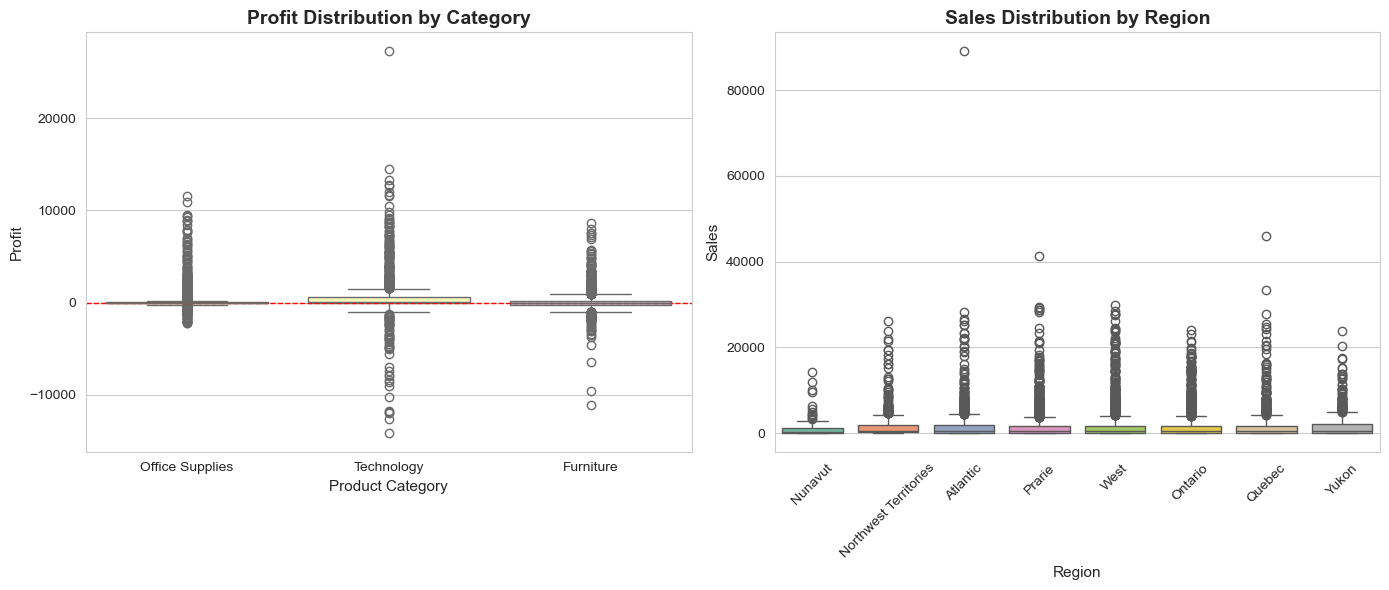

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='Product Category', y='Profit', ax=axes[0], palette='Set3')
axes[0].set_title('Profit Distribution by Category')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)

sns.boxplot(data=df, x='Region', y='Sales', ax=axes[1], palette='Set2')
axes[1].set_title('Sales Distribution by Region')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


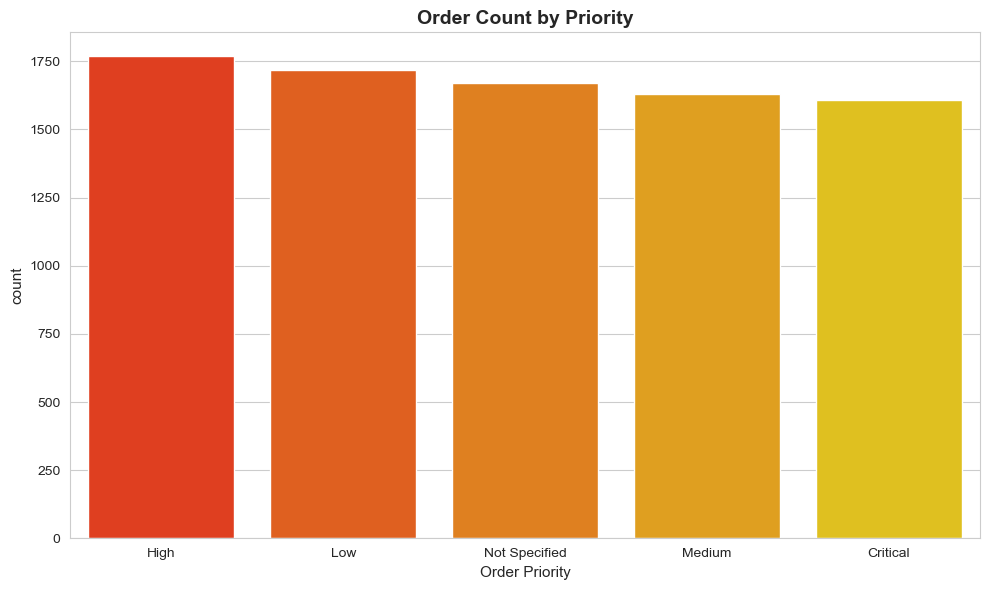

In [37]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Order Priority',
              order=df['Order Priority'].value_counts().index, palette='autumn')
plt.title('Order Count by Priority')
plt.tight_layout()
plt.show()


In [38]:
ship_mode_perf = df.groupby('Ship Mode').agg(
    Orders=('Order ID', 'nunique'),
    Avg_Shipping_Cost=('Shipping Cost', 'mean'),
    Avg_Shipping_Duration=('Shipping Duration', 'mean')
).sort_values('Orders', ascending=False)
ship_mode_perf


,Orders,Avg_Shipping_Cost,Avg_Shipping_Duration
Ship Mode,,,
Regular Air,4541,7.66,2.04
Delivery Truck,1081,45.35,2.04
Express Air,931,7.99,2.00


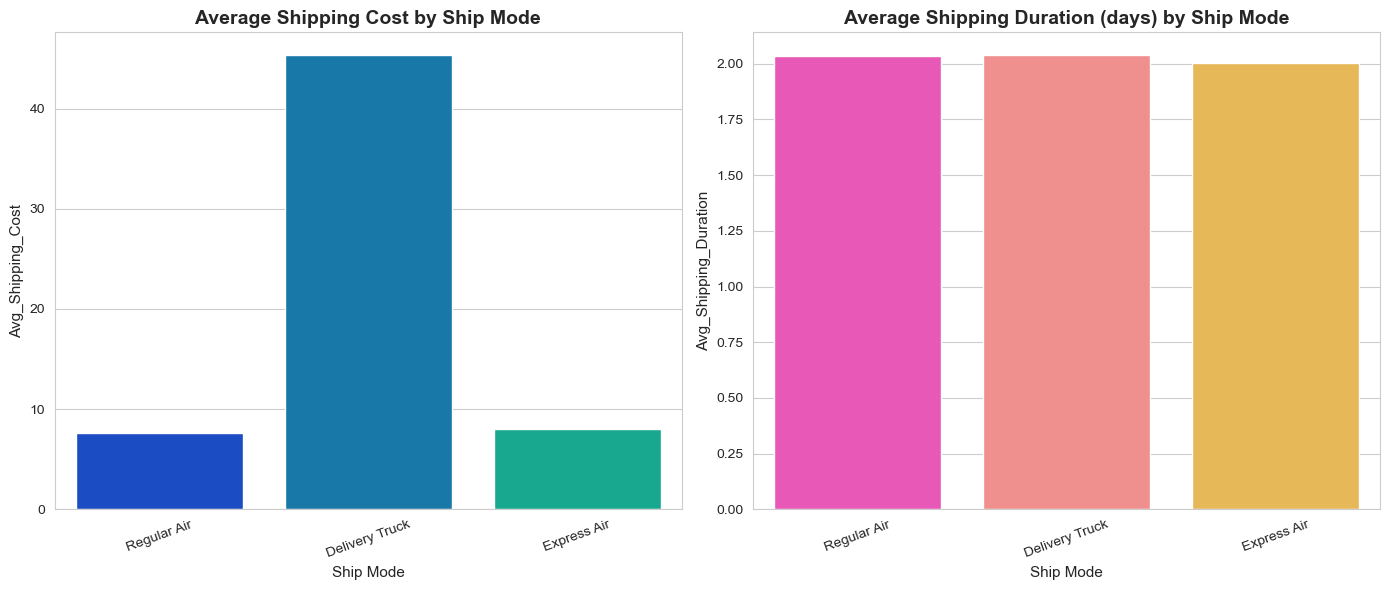

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=ship_mode_perf.index, y=ship_mode_perf['Avg_Shipping_Cost'], ax=axes[0], palette='winter')
axes[0].set_title('Average Shipping Cost by Ship Mode')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(x=ship_mode_perf.index, y=ship_mode_perf['Avg_Shipping_Duration'], ax=axes[1], palette='spring')
axes[1].set_title('Average Shipping Duration (days) by Ship Mode')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


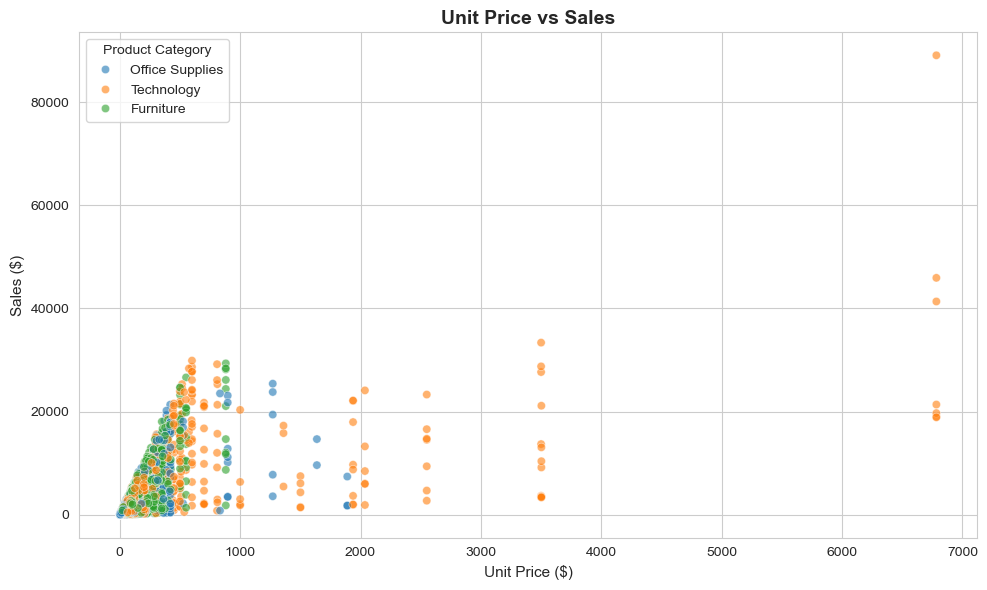

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Unit Price', y='Sales', hue='Product Category', alpha=0.6)
plt.title('Unit Price vs Sales')
plt.xlabel('Unit Price ($)')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()


<a id='15'></a>
## 15. Key Business Insights & Conclusions

Based on the analysis above:

1. **Sales vs Profit gap:** Some sub-categories (and specific products) generate high sales but negative or thin profit margins — these are worth reviewing for pricing or discount strategy.
2. **Discounting hurts profitability:** Profit margin declines sharply once discounts move past the 20–30% range, suggesting a cap or tighter discount governance could protect margins.
3. **Category performance is uneven:** One or two product categories drive the majority of both sales and profit, while others (or specific sub-categories within them) are consistent underperformers or even loss-makers.
4. **Regional concentration:** Sales and profit are not evenly distributed across regions — some regions significantly outperform others, which could guide targeted marketing or logistics investment.
5. **Seasonality exists:** Monthly sales show clear peaks and troughs across the year, useful for inventory planning and promotional timing.
6. **Customer concentration:** A small number of customers contribute a disproportionate share of sales — a good target for loyalty/retention programs.
7. **Shipping trade-offs:** Faster ship modes come with higher shipping costs, which is an operational cost/speed trade-off to weigh against customer satisfaction.
8. **Correlations:** Sales and Profit are positively correlated but not perfectly — high sales do not guarantee high profit, reinforcing the need to track profit margin (not just revenue) as a KPI.

### 📌 Recommended Next Steps
- Investigate and potentially discontinue or reprice consistently loss-making sub-categories/products.
- Set discount thresholds informed by the discount-vs-profit relationship found above.
- Double down on top-performing regions/categories while running targeted campaigns for weaker ones.
- Build a customer segmentation/RFM model on top of this dataset for deeper personalization.
